# Kaggle Competition info:
## NVIDIA Nemotron Model Reasoning Challenge
#### Advance reasoning techniques using NVIDIA Nemotron open models on a novel benchmark

## Overview
Develop techniques that improve reasoning accuracy using NVIDIA Nemotron models.

Participants will experiment with prompting, data pipelines, and lightweight fine-tuning while evaluating their approaches on a new reasoning benchmark developed by NVIDIA Research.

**Link:** <https://www.kaggle.com/competitions/nvidia-nemotron-model-reasoning-challenge/overview>

## Install libary

In [1]:
# install_DIR= "kaggle/input/datasets/johnsonhk88"
# # Install deepeval package
# !pip install deepeval  --no-index --no-deps --find-links=file:////{install_DIR}/deepeval-4-0-2/deepeval-package/deepeval-4.0.2-py3-none-any.whl
# !pip install portalocker --no-index --no-deps --find-links=file:////{install_DIR}/deepeval-4-0-2/deepeval-package/portalocker-3.2.0-py3-none-any.whl
# !pip install posthog --no-index --no-deps --find-links=file:////{install_DIR}/deepeval-4-0-2/deepeval-package/posthog-7.15.0-py3-none-any.whl
# !pip install pyfiglet --no-index --no-deps --find-links=file:////{install_DIR}/deepeval-4-0-2/deepeval-package/pyfiglet-1.0.4-py3-none-any.whl

# # Install Mlflow
# !pip install mlflow --no-index --no-deps --find-links=file:////{install_DIR}/mlflow/mlflow-package/mlflow-3.12.0-py3-none-any.whl
# !pip install mlflow_skinny --no-index --no-deps --find-links=file:////{install_DIR}/mlflow/mlflow-package/mlflow_skinny-3.12.0-py3-none-any.whl
# !pip install mlflow_tracing --no-index --no-deps --find-links=file:////{install_DIR}/mlflow/mlflow-package/mlflow_tracing-3.12.0-py3-none-any.whl
# !pip install databricks-sdk --no-index --no-deps --find-links=file:////{install_DIR}/mlflow/mlflow-package/databricks_sdk-0.110.0-py3-none-any.whl

# # !pip install --no-build-isolation -q "mamba-ssm>=2.2" causal-conv1d
# !pip install causal-conv1d  --no-index --no-deps --find-links=file:////kaggle/input/datasets/grooking/mamba-ssm/causal_conv1d-1.6.1-cp312-cp312-linux_x86_64.whl
# !pip install mamba-ssm  --no-index --no-deps --find-links=file:////kaggle/input/datasets/grooking/mamba-ssm/mamba_ssm-2.3.1-cp312-cp312-linux_x86_64.whl

# !pip install bitsandbytes --no-index --no-deps --find-links=file:////{install_DIR}/bitsandbytes/bitsandbytes-package/bitsandbytes-0.48.0-py3-none-manylinux_2_24_x86_64.whl
# !pip install trl --no-index --no-deps --find-links=file:////{install_DIR}/trl-transformers-reinforcement-learning/trl-package/trl-1.2.0-py3-none-any.whl

# !pip install unsloth --no-index --no-deps --find-links=file:////{install_DIR}/unsloth/unsloth-package/unsloth-2026.5.5-py3-none-any.whl
# !pip install unsloth-zoo  --no-index   --no-deps  --find-links=file:////{install_DIR}/unsloth/unsloth-package/unsloth_zoo-2026.5.5-py3-none-any.whl

# !pip install xformers   --no-index --no-deps  --find-links=file:////{install_DIR}/xformers/xformers-package/xformers-0.0.35-py39-none-manylinux_2_28_x86_64.whl
# !pip install flash-attn  --no-index --no-deps  --find-links=file:////kaggle/input/datasets/rezaazami/flash-attn-2-torch210-h100/flash_attn-2.8.4-cp312-cp312-linux_x86_64.whl


In [1]:
!nvidia-smi

Fri Jun  5 16:05:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 5000 Blac...    On  |   00000000:04:00.0 Off |                  Off |
| 50%   36C    P8              5W /  300W |       2MiB /  48935MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!nvcc -V

/bin/bash: line 1: nvcc: command not found


In [3]:
!ls /usr/local/cuda* 2>/dev/null || echo "No /usr/local/cuda found"

/usr/local/cuda:
bin  compat  include  lib64  nvvm  targets

/usr/local/cuda-13:
bin  compat  include  lib64  nvvm  targets

/usr/local/cuda-13.2:
bin  compat  include  lib64  nvvm  targets


In [4]:
!find /usr -name nvcc 2>/dev/null | head -5

/usr/local/cuda-13.2/bin/nvcc


In [5]:
# !export PATH=/usr/local/cuda-13.2/bin:$PATH
# !export LD_LIBRARY_PATH=/usr/local/cuda-13.2/lib64:$LD_LIBRARY_PATH

# # Make it permanent for this session
# !echo 'export PATH=/usr/local/cuda-13.2/bin:$PATH' >> ~/.bashrc
# !echo 'export LD_LIBRARY_PATH=/usr/local/cuda-13.2/lib64:$LD_LIBRARY_PATH' >> ~/.bashrc
# !sh ~/.bashrc

In [6]:
# !sh ~/.bashrc

In [7]:
# !nvcc -V

In [11]:
# 1. Check current disk usage
!df -h

# 2. Clean pip cache (this often frees a lot of space)
!pip cache purge

# 3. Remove old build artifacts and temp files
!rm -rf /tmp/* ~/.cache/pip /root/.cache/pip 2>/dev/null || true

# 4. Clean old logs and unnecessary files
!rm -rf ~/.cache 2>/dev/null || true

Filesystem      Size  Used Avail Use% Mounted on
overlay          16G   13G  3.1G  82% /
tmpfs            64M     0   64M   0% /dev
shm              28G     0   28G   0% /dev/shm
/dev/nvme0n1p1  7.0T  1.1T  6.0T  16% /etc/hosts
tmpfs            18G  2.0M   18G   1% /run/nvidia-persistenced/socket
/dev/sda2       195G   16G  170G   9% /usr/bin/nvidia-smi
tmpfs           4.0K  4.0K     0 100% /run/nvidia-ctk-hookfeb5aea5-5590-4e8e-99a5-74e555d3ad83
tmpfs            87G     0   87G   0% /proc/asound
tmpfs            87G     0   87G   0% /proc/acpi
tmpfs            87G     0   87G   0% /proc/scsi
tmpfs            87G     0   87G   0% /sys/firmware
Files removed: 988


In [12]:
!sh setup.sh

 Vast.ai PyTorch Template + Setup

[1/4] Upgrading pip...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 1.3 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 3.3 MB/s eta 0:00:00:--:--
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-proto 1.42.1 requires protobuf<7.0,>=5.0, but you have protobuf 7.35.0 which is incompatible.
databricks-sdk 0.110.0 requires protobuf!=5.26.*,!=5.27.*,!=5.28.*,!=5.29.0,!=5.29.1,!=5.29.2,!=5.29.3,!=5.29.4,!=6.30.0,!=6.30.1,!=6.31.0,<7.0,>=4.25.8, but you have protobuf 7.35.0 which is incompatible.
unsloth-zoo 2026.6.1 requires datasets!=4.0.*,!=4.1.0,<4.4.0,>=3.4.1, but you have datasets 5.0.0 which is incompatible.
unsloth-zoo 2026.6.1 requires trl!=0.19.0,<=0.24.0,>=0.18.2; sys_platform != "darwin" or platform_machine != "arm64", but you have trl 1.2.0 which is incompat

In [9]:
# !pip install posthog==7.15.0
# !pip install portalocker==3.2.0
# !pip install pyfiglet==1.0.4
# !pip install databricks-sdk==0.110.0

In [3]:
# !pip install -q triton
# !pip install --no-build-isolation -q "mamba-ssm>=2.2" causal-conv1d

In [4]:
import triton
# import mamba_ssm
# import bitsandbytes

print(triton.__version__)
# print(mamba_ssm.__version__)
# print(bitsandbytes.__version__)

3.6.0


In [6]:
!pip install pandas

In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
import deepeval
import mlflow

ModuleNotFoundError: No module named 'pandas'

In [6]:
from deepeval.metrics import GEval                     # ← Only this is needed
from deepeval.test_case import LLMTestCase
from deepeval import evaluate

In [7]:
# from trl import DPOTrainer, DPOConfig
# from peft import PeftModel, LoraConfig
# from datasets import load_dataset
# import torch

import os, glob, sys, subprocess, site, importlib.util, shutil, stat, types, re

import datasets
import kagglehub

import torch
# import mamba_ssm later

from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from trl import SFTTrainer, SFTConfig
from trl import GRPOConfig, GRPOTrainer
from unsloth import FastLanguageModel

import pandas as pd
import random
import gc, time

import json, zipfile

/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:144: UserWarning: WARNING: Unsloth should be imported before [trl, transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [8]:
import pandas as pd
import torch
import gc
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, PeftModel
from typing import Optional, Tuple, Dict


import kagglehub
# import mamba_ssm
# from trl import GRPOConfig, GRPOTrainer

In [9]:
import numpy as np
from sklearn.metrics import f1_score, recall_score, precision_score

In [ ]:
import os
from huggingface_hub import snapshot_download

class CFG:
    BASE_DIR   = "/workspace"                    # ← Standard on RunPod
    DATA_DIR   = os.path.join(BASE_DIR, "data")
    MODEL_DIR  = os.path.join(BASE_DIR, "models")
    OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
    MLFLOW_DIR = os.path.join(BASE_DIR, "mlruns")

    os.makedirs(DATA_DIR, exist_ok=True)
    os.makedirs(MODEL_DIR, exist_ok=True)
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    os.makedirs(MLFLOW_DIR, exist_ok=True)

    trainFile = os.path.join(DATA_DIR, "train.csv")
    testFile  = os.path.join(DATA_DIR, "test.csv")

    # Use Hugging Face directly
    BASE_MODEL = "nvidia/NVIDIA-Nemotron-3-Nano-30B-A3B-Base-BF16"

    SFT = True
    GRPO = False

In [11]:
mlflow_local= True # suitable for kaggle envirorment
# OUTPUT_DIR = "./model-finetuned"
MLFLOW_EXPERIMENT = "Nemoton-Reasoning-Fine-Tuning"


if mlflow_local:
    mlflowUrl = "sqlite:///mlflow.db" # for local sqlite db (recommend)
    # mlflowUrl = "file:///mlruns" # for local file 

else:
    # localhost
    mlflowUrl = "http://localhost:5000"




def setup_mlflow_run(
    experiment_name: str = "wonderland_nemotron_reasoning",
    run_name_suffix: str = "",
    train: bool = True
):
    """
    Separate MLflow setup function.
    Sets tracking URI, experiment, starts a run, and returns the active run context.
    """
    # project setup
    mlflow.set_tracking_uri(mlflowUrl)
    mlflow.set_experiment(experiment_name)

    # === CRITICAL: End any previously active run to prevent conflict ===
    try:
        mlflow.end_run()          # safely ends any lingering run
    except:
        pass                      # no active run → ignore
    
    run_name = f"eval_{run_name_suffix}"
    run = mlflow.start_run(run_name=run_name)
    print(f"MLflow run started: {run_name} (ID: {run.info.run_id})")
    return run

    if train:
        run_name = f"train_{run_name_suffix}"
    else:
        run_name = f"eval_{run_name_suffix}"
    run = mlflow.start_run(run_name=run_name)
    print(f"MLflow run started: {run_name} (ID: {run.info.run_id})")
    return run
        
    


In [12]:
def clearMemory():
    for _ in range(5):
        torch.cuda.empty_cache()
        gc.collect()
        time.sleep(0.3)

In [13]:
clearMemory()

## Load Dataset

In [14]:
# ====================== DATASET LOADING ======================
def load_train_data() -> pd.DataFrame:
    """Load the full training dataset (train.csv)"""
    df = pd.read_csv(CFG.trainFile)
    print(f"✅ Loaded train dataset: {len(df):,} examples")
    return df


def load_val_data(val_size: int = 400) -> pd.DataFrame:
    """Load a fixed validation split from train.csv (same samples every run)"""
    train_df = load_train_data()
    if val_size > len(train_df):
        print(f"⚠️  Requested val_size ({val_size}) > available data. Using all {len(train_df)} samples.")
        val_size = len(train_df)
    val_df = train_df.sample(n=val_size, random_state=42).reset_index(drop=True)
    print(f"✅ Created fixed validation split: {len(val_df)} examples")
    return  train_df , val_df


def load_test_data() -> pd.DataFrame:
    """Load the official test dataset (test.csv) for final inference"""
    df = pd.read_csv(CFG.testFile)
    print(f"✅ Loaded test dataset: {len(df)} examples")
    return df

In [15]:
trainDF, valDF = load_val_data(200)


✅ Loaded train dataset: 9,500 examples
✅ Created fixed validation split: 200 examples


In [16]:
# trainDF
valDF

,id,prompt,answer
0,18c797f1,"In Alice's Wonderland, a secret bit manipulati...",11100111
1,b13d511a,"In Alice's Wonderland, a secret set of transfo...",\&[[
2,71cd0e14,"In Alice's Wonderland, numbers are secretly co...",XXV
3,452b0241,"In Alice's Wonderland, a secret unit conversio...",20.72
4,7a4063e6,"In Alice's Wonderland, a secret bit manipulati...",10010110
...,...,...,...
195,f20e64f5,"In Alice's Wonderland, the gravitational const...",221.54
196,b8738676,"In Alice's Wonderland, secret encryption rules...",wizard sees inside tower
197,233ba645,"In Alice's Wonderland, numbers are secretly co...",XCIX
198,6445da05,"In Alice's Wonderland, a secret unit conversio...",64.35


In [17]:
testDF =  load_test_data()
testDF

✅ Loaded test dataset: 3 examples


,id,prompt
0,00066667,"In Alice's Wonderland, a secret bit manipulati..."
1,000b53cf,"In Alice's Wonderland, a secret bit manipulati..."
2,00189f6a,"In Alice's Wonderland, secret encryption rules..."


In [18]:
print(trainDF["prompt"][0])

In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.

Here are some examples of input -> output:
01010001 -> 11011101
00001001 -> 01101101
00010101 -> 01010101
11111111 -> 10000001
10011101 -> 01000101
00111011 -> 00001001
10111101 -> 00000101
00100110 -> 10110011

Now, determine the output for: 00110100


# Load Model

In [ ]:
# BASE_MODEL_PATH = kagglehub.model_download("metric/nemotron-3-nano-30b-a3b-bf16/transformers/default")
# Download model to persistent storage (do this once)
local_model_path = os.path.join(CFG.MODEL_DIR, "nemotron-3-nano-30b-base-bf16")

if not os.path.exists(os.path.join(local_model_path, "config.json")):
    print("Downloading Nemotron-3-Nano from Hugging Face...")
    snapshot_download(
        repo_id=CFG.BASE_MODEL,
        local_dir=local_model_path,
        local_dir_use_symlinks=False,
        resume_download=True
    )
    print(f"✅ Model saved to: {local_model_path}")
local_model_path

'/kaggle/input/models/metric/nemotron-3-nano-30b-a3b-bf16/transformers/default/1'

In [20]:
UNSLOTH_VERSION = True
MAX_SEQ_LENGTH = 4096
LOAD_IN_4BIT = False

In [21]:
if UNSLOTH_VERSION:
    def load_model(
        model_name: str,
        adapter_path: Optional[str] = None
    ) -> Tuple[AutoModelForCausalLM, AutoTokenizer]:
        print(f"Loading unsloth model: {model_name} {'+ adapter: ' + adapter_path if adapter_path else '(base)'}")    
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=model_name,
            max_seq_length=MAX_SEQ_LENGTH,
            load_in_4bit=LOAD_IN_4BIT,
            trust_remote_code=True,
        )

        model = FastLanguageModel.get_peft_model(
            model,
            r=16,
            lora_alpha=32,
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
            lora_dropout=0.05,
            bias="none",
            use_gradient_checkpointing="unsloth", #"unsloth",   # Best for memory + stability
            random_state=3407,
        )
        return model, tokenizer
        
else:
    def load_model(
        model_name: str,
        adapter_path: Optional[str] = None
    ) -> Tuple[AutoModelForCausalLM, AutoTokenizer]:
        """Load base model + optional LoRA adapter."""
        print(f"Loading model: {model_name} {'+ adapter: ' + adapter_path if adapter_path else '(base)'}")
        
        # === Model + LoRA (Mamba/MoE stable config) ===
        # bnb_config = BitsAndBytesConfig(
        #     load_in_4bit=True,                    # ← Change from 8-bit to 4-bit
        #     bnb_4bit_quant_type="nf4",            # nf4 is best for most models
        #     bnb_4bit_use_double_quant=True,       # Saves extra memory + more stable
        #     bnb_4bit_compute_dtype=torch.bfloat16,  # or torch.float16
        # )
        # === Model + LoRA (8-bit + smaller rank = stable for Mamba) ===
        # bnb_config = BitsAndBytesConfig(
        #     load_in_8bit=True,                    # ← Changed to 8-bit (more stable)
        #     # bnb_4bit_compute_dtype=torch.bfloat16,
        #     bnb_4bit_compute_dtype=torch.float16,
        # )
    
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            # quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True,
            dtype=torch.bfloat16,
            # dtype=torch.float16 # for 8bit
        )
    
        if adapter_path:
            model = PeftModel.from_pretrained(model, adapter_path)
    
        tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token

        print("LoRA Configure")
        lora_config = LoraConfig(
            r=16,
            lora_alpha=32,
            target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
            lora_dropout=0.05,
            bias="none",
            task_type="CAUSAL_LM")
        model = get_peft_model(model, lora_config)
        model.print_trainable_parameters()
    
        return model, tokenizer

## Load base model

In [22]:

# del model
# del tokenizer

In [23]:
clearMemory()

In [ ]:
if CFG.SFT:
    model, tokenizer = load_model(local_model_path, None)

Loading unsloth model: /kaggle/input/models/metric/nemotron-3-nano-30b-a3b-bf16/transformers/default/1 (base)
Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.5.5: Fast Nemotron_H patching. Transformers: 5.0.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights:   0%|          | 0/6243 [00:00<?, ?it/s]

/kaggle/input/models/metric/nemotron-3-nano-30b-a3b-bf16/transformers/default/1 does not have a padding token! Will use pad_token = <SPECIAL_999>.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


Unsloth: Detected MoE model with num_experts = 128 and target_modules = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']. Enabling LoRA on MoE parameters: ['mlp.experts.gate_up_proj', 'mlp.experts.down_proj']
Unsloth: PEFT set target_parameters but found no matching parameters.
This is expected for MoE models - Unsloth handles MoE expert LoRA targeting separately.


## Evaluation function

In [25]:
import re
import difflib

def extract_answer(text: str) -> str:
    """
    Robust answer extraction aligned with Kaggle-style evaluation.
    Priority order:
    1. Content inside \boxed{}
    2. Clean last meaningful line
    3. Last alphanumeric token
    """
    if not text or not isinstance(text, str):
        return ""
    
    text = text.strip()
    
    # === Priority 1: Extract from \boxed{} ===
    boxed_match = re.search(r'\\boxed\{([^}]+)\}', text)
    if boxed_match:
        answer = boxed_match.group(1).strip()
        # Clean common junk inside boxed
        answer = re.sub(r'^(output|answer|final answer)[:\s]*', '', answer, flags=re.IGNORECASE)
        return answer.strip()
    
    # === Priority 2: Remove common unwanted patterns ===
    # Remove refusal / sorry messages
    if any(x in text.lower() for x in ["i'm sorry", "i cannot", "i can't", "sorry"]):
        return ""
    
    # Remove obvious reasoning lines
    lines = [line.strip() for line in text.split('\n') if line.strip()]
    
    # Filter out lines that look like reasoning/explanation
    clean_lines = []
    for line in lines:
        lower = line.lower()
        if any(x in lower for x in ["reason", "explain", "because", "rule is", "so the", "therefore", "output:"]):
            continue
        clean_lines.append(line)
    
    if clean_lines:
        # Take the last clean line
        candidate = clean_lines[-1]
        
        # Remove common prefixes
        candidate = re.sub(r'^(output|answer|final answer|result)[:\s]*', '', candidate, flags=re.IGNORECASE)
        candidate = candidate.strip()
        
        if candidate:
            return candidate
    
    # === Priority 3: Last meaningful token ===
    tokens = re.findall(r'[0-9a-zA-Z\.\-\_\/]+', text)
    if tokens:
        return tokens[-1]
    
    return text.strip()

In [26]:
def is_correct(pred: str, gt: str, tolerance: float = 0.01) -> float:
    pred = pred.strip().lower()
    gt = gt.strip().lower()
    
    if pred == gt:
        return 1.0
    
    # Numerical tolerance
    try:
        p = float(pred)
        g = float(gt)
        if g == 0:
            return 1.0 if abs(p) < tolerance else 0.0
        return 1.0 if abs(p - g) / abs(g) <= tolerance else 0.0
    except:
        pass
    
    # String similarity fallback
    similarity = difflib.SequenceMatcher(None, pred, gt).ratio()
    return 1.0 if similarity > 0.92 else 0.0

In [27]:
def run_evaluation(
    model,
    tokenizer,
    val_size: int = 400,
    experiment_name: str = "wonderland_nemotron_reasoning",
    run_name_suffix: str = ""
) -> Dict:
    run = setup_mlflow_run(experiment_name, run_name_suffix)

    mlflow.log_param("val_size", val_size)
    mlflow.log_param("generation_method", "apply_chat_template + greedy_generate")

    test_cases = []
    exact_matches = []
    start_time = time.time()

    print(f"Running evaluation on {val_size} samples using direct generate...")

    if UNSLOTH_VERSION:
        FastLanguageModel.for_inference(model)
    for idx, row in enumerate(valDF.iterrows(), start=1):
        _, row = row  # unpack
        prompt = row['prompt']
        gt = str(row['answer']).strip()

        print(f"Eval Sample: {idx}")
#         full_prompt = f"""<|system|>You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles. Analyze the examples carefully and output ONLY the final answer.</s>
# <|user|>{prompt}</s>
# <|assistant|>"""

#         full_prompt = f"""<|system|>You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles.
# You MUST output ONLY the final answer. Do not explain, do not show reasoning, do not write "the answer is", do not add any text before or after the answer.</s>
# <|user|>{prompt}</s>
# <|assistant|>"""

        full_prompt = f"""<|system|>You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles.
Analyze the examples carefully and determine the hidden rule.
**Output ONLY the final answer inside \\boxed{{}}.**
Do not explain your reasoning. Do not write any text before or after the boxed answer.
<|user|>{prompt}
<|assistant|>"""

        # messages = [
        #     {"role": "system", "content": "You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles. Analyze the examples carefully and output ONLY the final answer."},
        #     {"role": "user", "content": prompt}
        # ]
        # messages = [
        #     {
        #         "role": "system",
        #         "content": "You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles. "
        #                    "Analyze the examples carefully, but output ONLY the final answer. "
        #                    "Do NOT explain, do NOT show reasoning, do NOT write 'the answer is', "
        #                    "do NOT add any text before or after the answer. Just output the result."
        #     },
        #     {"role": "user", "content": prompt}
        # ]
        
        # full_prompt = tokenizer.apply_chat_template(
        #     messages,
        #     tokenize=False,
        #     add_generation_prompt=True,
        #     # return_tensors="pt"
        #     # enable_thinking=enable_thinking
        # )
        
        # Tokenize as string → tensor
        tokenized = tokenizer(
            full_prompt,
            return_tensors="pt",
            add_special_tokens=True
        )

        input_ids = tokenized.input_ids.to(model.device)
        input_len = tokenized["input_ids"].shape[-1]
        attention_mask = tokenized.attention_mask.to(model.device)

        # === Generate ===
        outputs = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=256,
            do_sample=False,
            num_beams=1,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )
        
        # === CLEAN DECODING (new) ===
        generated_tokens = outputs[0][input_len:]
        full_output = tokenizer.decode(generated_tokens, skip_special_tokens=False)
        
        # Extract only assistant response
        if "<|assistant|>" in full_output:
            raw_pred = full_output.split("<|assistant|>")[-1]
        else:
            raw_pred = full_output
        
        # Clean special tokens
        special_tokens = ["<|im_end|>", "<|endoftext|>", "</s>", "<|eot_id|>", "<|im_start|>"]
        for token in special_tokens:
            raw_pred = raw_pred.replace(token, "").strip()
        
        # === Use robust extraction ===
        pred = extract_answer(raw_pred)
        
        # pred = pred.strip()   # final clean
        print(f"Exact ans: {gt.lower().strip()}")
        print(f"Pred ans: { pred.lower().strip()}\n")
        

        # is_exact = 1.0 if pred.lower().strip() == gt.lower().strip() else 0.0
        # exact_matches.append(is_exact)
        # Then in the loop:
        is_exact = is_correct(pred, gt)
        exact_matches.append(is_exact)
        print(f"Matches = {is_exact}")
        print("-"*20)

        test_case = LLMTestCase(input=prompt, actual_output=pred, expected_output=gt)
        test_cases.append(test_case)

        if idx % 5 == 0 or idx == len(valDF):
            print(f"   Processed {idx}  samples...")
        
        if idx>= val_size:
            break
        

    # Metrics
    avg_exact_match = sum(exact_matches) / val_size
    mlflow.log_metric("exact_match", avg_exact_match)
    mlflow.log_metric("eval_time_sec", time.time() - start_time)
    mlflow.log_metric("samples_evaluated", val_size)

    # DeepEval require external LLM implement, but competition not allow access internet 
    # correctness_metric = GEval(
    #     name="Answer Correctness",
    #     criteria="Determine whether the actual output exactly matches the expected output. Be strict.",
    #     evaluation_params=["actual_output", "expected_output"],
    # )
    # rule_quality_metric = GEval(
    #     name="Rule Discovery Quality",
    #     criteria="Does the model correctly discover the hidden transformation rule from the examples and apply it accurately?",
    #     evaluation_params=["actual_output", "expected_output"],
    # )

    # print("Running DeepEval GEval...")
    # results = evaluate(test_cases, [correctness_metric, rule_quality_metric], verbose=False)

    # mlflow.log_metric("deepeval_answer_correctness", results[0].score)
    # mlflow.log_metric("deepeval_rule_quality", results[1].score)

    print(f"\n=== EVALUATION RESULTS ===")
    # print(f"Exact Match (manual):       {avg_exact_match:.4f}")
    # print(f"DeepEval Correctness:       {results[0].score:.4f}")
    # print(f"DeepEval Rule Quality:      {results[1].score:.4f}")
    # print(f"Evaluation time:            {time.time() - start_time:.1f} seconds")
    print(f"\n=== EVALUATION RESULTS (on exactly {len(valDF)} samples) ===")
    print(f"Exact Match Accuracy: {avg_exact_match:.4f} ({int(avg_exact_match*val_size)}/{val_size})")
    mlflow.end_run()

    return {
        # "exact_match": avg_exact_match,
        # "deepeval_correctness": results[0].score,
        # "deepeval_rule_quality": results[1].score,
        "exact_match": avg_exact_match,
        "samples_used": val_size
    }

        
    

In [28]:
def evaluate_model(
    # model_name: str,
    # adapter_path: Optional[str] = None,
    model,
    tokenizer,
    val_size: int = 400,
    experiment_name: str = "wonderland_nemotron_reasoning",
    suffix= "base"
):
    """Convenience wrapper"""
    return run_evaluation(model, tokenizer, val_size, experiment_name, run_name_suffix=suffix)

## Evaluate base model

In [29]:
if CFG.SFT:
    evaluate_model(
        # model_name= BASE_MODEL_PATH,
        model,
        tokenizer,
        val_size=10
    )

2026/06/05 01:46:20 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/05 01:46:20 INFO mlflow.store.db.utils: Updating database tables
2026/06/05 01:46:22 INFO mlflow.tracking.fluent: Experiment with name 'wonderland_nemotron_reasoning' does not exist. Creating a new experiment.


MLflow run started: eval_base (ID: 9916b28ccbd74089bda1c1baec303bb9)
Running evaluation on 10 samples using direct generate...
Eval Sample: 1


[transformers_modules._1.modeling_nemotron_h|WARNING]NemotronH requires an initialized `NemotronHHybridDynamicCache` to return a cache. None was provided, so no cache will be returned.


Exact ans: 11100111
Pred ans: 10110100

Matches = 0.0
--------------------
Eval Sample: 2
Exact ans: \&[[
Pred ans: input: 1:< 2:[ 3:+ 4:& 5:<

Matches = 0.0
--------------------
Eval Sample: 3
Exact ans: xxv
Pred ans: xxv

Matches = 1.0
--------------------
Eval Sample: 4
Exact ans: 20.72
Pred ans: 

Matches = 0.0
--------------------
Eval Sample: 5
Exact ans: 10010110
Pred ans: 01001101

Matches = 0.0
--------------------
   Processed 5  samples...
Eval Sample: 6
Exact ans: 00000111
Pred ans: 10110111

Matches = 0.0
--------------------
Eval Sample: 7
Exact ans: {/"
Pred ans: 

Matches = 0.0
--------------------
Eval Sample: 8
Exact ans: lvi
Pred ans: xlvi

Matches = 0.0
--------------------
Eval Sample: 9
Exact ans: 01000000
Pred ans: 10100000

Matches = 0.0
--------------------
Eval Sample: 10
Exact ans: wizard follows inside wonderland
Pred ans: so q

Matches = 0.0
--------------------
   Processed 10  samples...

=== EVALUATION RESULTS ===

=== EVALUATION RESULTS (on exactly 200 

In [30]:
experiments = mlflow.search_experiments()
for exp in experiments:
    print(f"Experiment ID: {exp.experiment_id}, Name: {exp.name}")

Experiment ID: 1, Name: wonderland_nemotron_reasoning
Experiment ID: 0, Name: Default


In [31]:
# baseEvalRet = mlflow.search_runs(experiment_ids=["1"])
baseEvalRet = mlflow.search_runs(search_all_experiments=True)
baseEvalRet

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.exact_match,metrics.samples_evaluated,metrics.eval_time_sec,params.val_size,params.generation_method,tags.mlflow.source.name,tags.mlflow.user,tags.mlflow.runName,tags.mlflow.source.type
0,9916b28ccbd74089bda1c1baec303bb9,1,FINISHED,/kaggle/working/mlruns/1/9916b28ccbd74089bda1c...,2026-06-05 01:46:22.443000+00:00,2026-06-05 01:52:05.083000+00:00,0.1,10.0,342.601383,10,apply_chat_template + greedy_generate,/usr/local/lib/python3.12/dist-packages/colab_...,root,eval_base,NOTEBOOK


# Single Test for debug 

In [32]:
# testPrompt = valDF.iloc[0]["prompt"]
# testAns = valDF.iloc[0]["answer"]
# testPrompt

In [33]:

# full_prompt = f"""<|system|>You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles.
# You MUST output ONLY the final answer. Do not explain, do not show reasoning, do not write "the answer is", do not add any text before or after the answer.
# <|user|>{testPrompt}
# <|assistant|>"""
# prompt = full_prompt

In [34]:
# messages = [
#             {"role": "system", "content": "You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles. Analyze the examples carefully and output ONLY the final answer."},
#             {"role": "user", "content": testPrompt}
#         ]

# prompt = tokenizer.apply_chat_template(
#     messages,
#     tokenize=False,
#     add_generation_prompt=True,
#     # return_tensors="pt"
#     # enable_thinking=enable_thinking
# )
# prompt

In [35]:
# tokenized = tokenizer(
#     prompt,
#     return_tensors="pt",
#     add_special_tokens=True
# )
# input_ids = tokenized.input_ids.to(model.device)
# input_len = tokenized["input_ids"].shape[-1]
# attention_mask = tokenized.attention_mask.to(model.device)

In [36]:

# === Generate ===
# outputs = model.generate(
#     input_ids,
#     attention_mask=attention_mask,
#     max_new_tokens=1024,
#     do_sample=False,
#     num_beams=1,
#     eos_token_id=tokenizer.eos_token_id,
#     pad_token_id=tokenizer.pad_token_id,
# )

In [37]:
# # Decode and extract answer
# === CLEAN DECODING (new) ===
# full_output = tokenizer.decode(outputs[0][input_len:], skip_special_tokens=False)

# # Extract only assistant response
# if "<|assistant|>" in full_output:
#     pred = full_output.split("<|assistant|>")[-1]
# else:
#     pred = full_output

# # Remove common special tokens
# special_tokens = ["<|im_end|>", "<|endoftext|>", "</s>", "<|eot_id|>", "<|im_start|>"]
# for token in special_tokens:
#     pred = pred.replace(token, "").strip()

# pred = pred.strip()   # final clean

In [38]:
# full_output

In [39]:
# pred

###
### Full SFT (Supervised Fine-Tuning) script for NVIDIA Nemotron challenge.
#### Uses real train.csv + modular functions from evaluation.py
###

In [40]:
# OUTPUT_ADAPTER = "/kaggle/working/sft_final"
SFT_ADAPTER = "/kaggle/working/sft_final"
OUTPUT_ADAPTER = "/kaggle/working/grpo_final"

In [41]:
# === NEW TRAINING PROMPT FORMAT (same as your working eval prompt) ===
def format_sft_example(row):
    prompt = row['prompt']
    answer = str(row['answer']).strip()
    
#     full_text = f"""<|system|>You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles.
# You MUST output ONLY the final answer. Do not explain, do not show reasoning, do not write "the answer is", do not add any text before or after the answer.
# <|user|>{prompt}
# <|assistant|>{answer}"""
    
    full_text = f"""<|system|>You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles.
Analyze the examples carefully and determine the hidden rule.
**Output ONLY the final answer inside \\boxed{{}}.**
Do not explain your reasoning. Do not write any text before or after the boxed answer.
<|user|>{prompt}
<|assistant|>\\boxed{{{answer}}}"""

    return {"text": full_text}

In [42]:
# === YOUR COMPUTE_METRIC FUNCTION (added here) ===
def compute_metric(eval_pred):
    logits, labels = eval_pred
    
    # Convert to numpy if needed
    if isinstance(logits, torch.Tensor):
        logits = logits.cpu().numpy()
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()

    # 1. Overall next-token accuracy (keep for reference)
    shift_logits = logits[..., :-1, :]
    shift_labels = labels[..., 1:]
    preds = np.argmax(shift_logits, axis=-1)
    mask = shift_labels != -100
    token_accuracy = (preds == shift_labels & mask).sum() / mask.sum() if mask.sum() > 0 else 0.0

    # 2. Last-token metrics (much more meaningful for puzzle solving)
    last_logits = logits[:, -1, :]           # shape: (batch, vocab)
    last_labels = labels[:, -1]              # shape: (batch,)
    
    top3_preds = np.argsort(last_logits, axis=-1)[:, -3:]
    match = (top3_preds == last_labels[:, None])
    predictions = top3_preds[:, 2]           # top-1 prediction

    last_token_acc = (predictions == last_labels).mean()

    f1score     = f1_score(last_labels, predictions, average='weighted', zero_division=1)
    recallScore = recall_score(last_labels, predictions, average='weighted', zero_division=1)
    precision   = precision_score(last_labels, predictions, average='weighted', zero_division=1)

    # MAP@3 on last token
    map3 = 0.0
    for i in range(len(last_labels)):
        if match[i, 0]:
            map3 += 1.0
        elif match[i, 1]:
            map3 += 1.0 / 2
        elif match[i, 2]:
            map3 += 1.0 / 3
    map3Score = map3 / len(last_labels)

    return {
        "accuracy": token_accuracy,           # overall next-token (for reference)
        "last_token_accuracy": last_token_acc, # ← most important
        "recall": recallScore,
        "precision": precision,
        "f1-score": f1score,
        "map_3": map3Score
    }

# === FULL METRICS (your request) - computed on last token ===
# === FIXED COMPUTE_METRIC (handles both torch and numpy) ===
# def compute_metric(eval_pred):
#     logits, labels = eval_pred
    
#     # Convert to numpy if they are tensors
#     if isinstance(logits, torch.Tensor):
#         logits = logits.cpu().numpy()
#     if isinstance(labels, torch.Tensor):
#         labels = labels.cpu().numpy()
    
#     # Token-level accuracy (next-token prediction)
#     shift_logits = logits[..., :-1, :]
#     shift_labels = labels[..., 1:]
#     preds = np.argmax(shift_logits, axis=-1)
#     mask = shift_labels != -100
#     token_accuracy = (preds == shift_labels & mask).sum() / mask.sum() if mask.sum() > 0 else 0.0

#     # Classification metrics on the LAST token only
#     last_logits = logits[:, -1, :]
#     last_labels = labels[:, -1]
#     top3_preds = np.argsort(last_logits, axis=-1)[:, -3:]
#     match = (top3_preds == last_labels[:, None])
#     predictions = top3_preds[:, 2]

#     acc = (predictions == last_labels).mean()
#     f1score = f1_score(last_labels, predictions, average='weighted', zero_division=1)
#     recallScore = recall_score(last_labels, predictions, average='weighted', zero_division=1)
#     precision = precision_score(last_labels, predictions, average='weighted', zero_division=1)

#     # MAP@3
#     # map3 = 0.0
#     # for i in range(len(last_labels)):
#     #     if match[i, 0]:
#     #         map3 += 1.0
#     #     elif match[i, 1]:
#     #         map3 += 1.0 / 2
#     #     elif match[i, 2]:
#     #         map3 += 1.0 / 3
#     # map3Score = map3 / len(last_labels)

#     return {
#         "accuracy": token_accuracy,
#         "last_token_accuracy": acc,
#         "recall": recallScore,
#         "precision": precision,
#         "f1-score": f1score,
#         # "map_3": map3Score
#     }
# def compute_metric(eval_pred):
#     logits, labels = eval_pred
#     if isinstance(logits, torch.Tensor):
#         logits = logits.cpu().numpy()
#     if isinstance(labels, torch.Tensor):
#         labels = labels.cpu().numpy()

#     shift_logits = logits[..., :-1, :]
#     shift_labels = labels[..., 1:]
#     preds = np.argmax(shift_logits, axis=-1)
#     mask = shift_labels != -100
#     token_accuracy = (preds == shift_labels & mask).sum() / mask.sum() if mask.sum() > 0 else 0.0

#     return {"accuracy": token_accuracy}

## Create Dataset

In [43]:
# COLS = ['text','a']
# trainDataset = Dataset.from_pandas(tempTrainDF[COLS], split="train")
dataset = Dataset.from_pandas(trainDF).map(format_sft_example, remove_columns=trainDF.columns.tolist())
dataset

Map:   0%|          | 0/9500 [00:00<?, ? examples/s]

Dataset({
    features: ['text'],
    num_rows: 9500
})

In [44]:

# === CREATE SMALL EVAL SPLIT FOR DEBUGGING ===
eval_size = 100 #50 #200
# eval_dataset = dataset.shuffle(seed=42).select(range(eval_size))
# train_dataset = dataset.shuffle(seed=42).select(range(eval_size, len(dataset)))
# print(f"✅ Train samples: {len(train_dataset)} | Eval samples: {len(eval_dataset)}")



In [45]:
# dataset["train"]
dataset = dataset.train_test_split(test_size=eval_size, seed=42, shuffle=True)
dataset

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 9400
    })
    test: Dataset({
        features: ['text'],
        num_rows: 100
    })
})

In [46]:
# def tokenizeFunc(batch):
#     return tokenizer(batch["text"],  max_length=2048, padding='max_length', truncation=True)

In [47]:
# dataset =  dataset.map(tokenizeFunc, batched=True)
# dataset

In [48]:
# === Training ===
EXPERIMENT_NAME= "wonderland_nemotron_reasoning"
run = setup_mlflow_run(EXPERIMENT_NAME, "sft_training")
mlflow.log_params({
    "max_lora_rank": 32,
    "max_tokens": 7680,
    "max_model_len": 8192,
    "temperature": 0.0,
    "top_p": 1.0,
    "eval_strategy": "steps",
    "save_strategy": "steps"
})

MLflow run started: eval_sft_training (ID: 3d26cf810e5641a89b220c7f5fce104f)


In [49]:
TOTAL_STEPS= 1200 #1000 #200 #1000 #100
SAVE_STEPS = TOTAL_STEPS  * 3 #// 1

In [50]:

from trl import SFTTrainer as OriginalSFTTrainer
if CFG.SFT: # use Supervised Fine Tuning
    torch_dtype = model.dtype
    if UNSLOTH_VERSION:
        FastLanguageModel.for_training(model)
        trainer = OriginalSFTTrainer(
            model = model,
            processing_class=tokenizer,
            train_dataset=dataset["train"],
            eval_dataset=dataset["test"],
            compute_metrics=compute_metric,
            args = SFTConfig(
                dataset_text_field = "text",
                per_device_train_batch_size=2,
                gradient_accumulation_steps=4,
                per_device_eval_batch_size=2,          # ← CRITICAL for OOM fix
                eval_accumulation_steps=4,             # ← CRITICAL for OOM fix
                warmup_steps = 5,
                num_train_epochs = 1, # Set this for 1 full training run.
                max_steps=TOTAL_STEPS, # for testing
                learning_rate = 2e-4, # Reduce to 2e-5 for long training runs
                logging_steps = 20,
    
    
                eval_strategy="steps",
                save_strategy="steps",  # avoid save a lot of checkpoint (limited space in ouput directory)
                eval_steps=100,           # evaluate every 50 steps (easy to debug)
                save_steps=SAVE_STEPS,           # save checkpoint every 50 steps
                save_total_limit=1,                # keep only last 2 checkpoints
                optim = "adamw_8bit",
                weight_decay = 0.001,
                lr_scheduler_type = "linear",
                seed = 3407,
                # metric_for_best_model="accuracy",      # ← your request
                # greater_is_better=True,                # ← your request
                load_best_model_at_end=False,
                
                # bf16=False,  #True,
                fp16=False, #if torch_dtype == torch.float16 else False,   # use float16 precision ,  # INFER WITH FP16 BECAUSE KAGGLE IS T4 GPU
                bf16=True,  # if torch_dtype == torch.bfloat16 else False,  # use bfloat16 precision, TRAIN WITH BF16 IF LOCAL GPU IS NEWER GPU 
                gradient_checkpointing=False,       # ← CRITICAL for Mamba model
                packing=False,                      # ← CRITICAL for Mamba model
                
                report_to = "mlflow", # Use TrackIO/WandB etc
            ),
        )
       
    
    else:
        training_args = SFTConfig(
            output_dir= "/kaggle/working" , #SFT_ADAPTER, 
            max_length=4096,
            per_device_train_batch_size=2,
            gradient_accumulation_steps=4,
            per_device_eval_batch_size=2,          # ← CRITICAL for OOM fix
            eval_accumulation_steps=4,             # ← CRITICAL for OOM fix
            learning_rate=1e-4,
            num_train_epochs=1,
            logging_steps=20,
        
            max_steps=TOTAL_STEPS, # for testing
            
            # === YOUR PREFERRED SETTINGS FOR FAST DEBUGGING ===
            eval_strategy="steps",
            save_strategy="steps",  # avoid save a lot of checkpoint (limited space in ouput directory)
            eval_steps=100,           # evaluate every 50 steps (easy to debug)
            save_steps=SAVE_STEPS,           # save checkpoint every 50 steps
            save_total_limit=1,                # keep only last 2 checkpoints
            # metric_for_best_model="accuracy",      # ← your request
            # greater_is_better=True,                # ← your request
            load_best_model_at_end=False,
            
            # bf16=False,  #True,
            fp16=False, #if torch_dtype == torch.float16 else False,   # use float16 precision ,  # INFER WITH FP16 BECAUSE KAGGLE IS T4 GPU
            bf16=True,  # if torch_dtype == torch.bfloat16 else False,  # use bfloat16 precision, TRAIN WITH BF16 IF LOCAL GPU IS NEWER GPU 
            gradient_checkpointing=False,       # ← CRITICAL for Mamba model
            packing=False,                      # ← CRITICAL for Mamba model
            report_to="mlflow",                  # ← THIS ENABLES MLflow logging during training
        )
        trainer = OriginalSFTTrainer(
            model=model,
            args=training_args,
            train_dataset=dataset["train"],
            eval_dataset=dataset["test"],
             # peft_config = lora_config, # not need ready pass PeftModel
            processing_class=tokenizer,
            # data_collator = data_collator,
            compute_metrics=compute_metric,
            # dataset_text_field="text",
        )


Unsloth: Tokenizing ["text"] (num_proc=52):   0%|          | 0/9400 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=52):   0%|          | 0/100 [00:00<?, ? examples/s]

In [51]:
# from transformers import DataCollatorWithPadding
# data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [52]:
if CFG.SFT:
    print("🚀 Starting SFT training with steps-based eval/save + metrics...")
    trainer.train()
    trainer.save_model(SFT_ADAPTER)
    print(f"✅ SFT completed → {SFT_ADAPTER}")

🚀 Starting SFT training with steps-based eval/save + metrics...


Step,Training Loss,Validation Loss,Accuracy,Last Token Accuracy,Recall,Precision,F1-score,Map 3
100,2.700971,0.590267,0.471018,0.000000,0.000000,1.000000,0.000000,0.000000
200,2.919439,0.568810,0.471018,0.000000,0.000000,1.000000,0.000000,0.000000
300,2.219546,0.557307,0.471018,0.000000,0.000000,1.000000,0.000000,0.000000
400,2.498132,0.551520,0.471018,0.000000,0.000000,1.000000,0.000000,0.000000
500,2.235064,0.546620,0.471018,0.000000,0.000000,1.000000,0.000000,0.000000
600,2.388321,0.542993,0.471018,0.000000,0.000000,1.000000,0.000000,0.000000
700,2.179101,0.536269,0.471018,0.000000,0.000000,1.000000,0.000000,0.000000
800,2.305897,0.534270,0.471018,0.000000,0.000000,1.000000,0.000000,0.000000
900,2.284088,0.529477,0.471018,0.000000,0.000000,1.000000,0.000000,0.000000
1000,2.147092,0.528439,0.471018,0.000000,0.000000,1.000000,0.000000,0.000000


Unsloth: Restored added_tokens_decoder metadata in trainer_output/checkpoint-1200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/sft_final/tokenizer_config.json.


✅ SFT completed → /kaggle/working/sft_final


In [53]:
if CFG.SFT:
    trainHistoryDF = pd.DataFrame(trainer.state.log_history)
    trainHistoryDF

In [54]:
# !rm -f -R /kaggle/working/sft_final # checkpoint-100/ 

In [55]:
if CFG.SFT:
    trainHistoryDF.columns

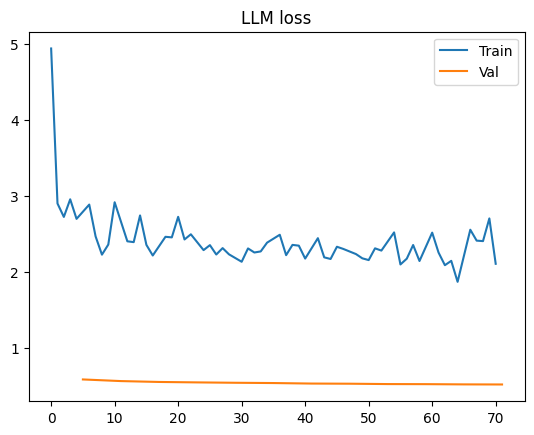

In [56]:
import matplotlib.pyplot as plt
if CFG.SFT:
    trainloss = trainHistoryDF[~trainHistoryDF["loss"].isnull()]
    valloss = trainHistoryDF[~trainHistoryDF["eval_loss"].isnull()]
    plt.plot(trainloss["loss"], label="Train")
    plt.plot(valloss["eval_loss"], label="Val")
    plt.title("LLM loss")
    plt.legend()
    plt.show()

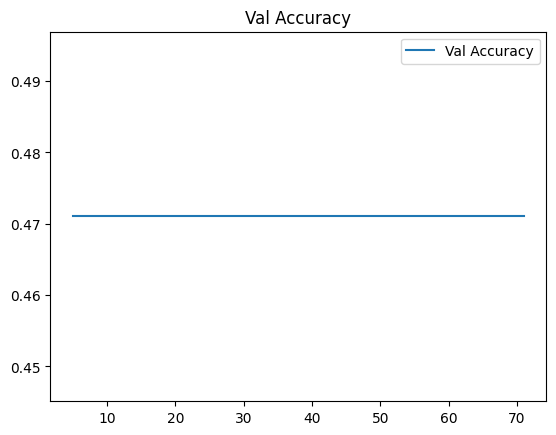

In [57]:
if CFG.SFT:
    trainloss = trainHistoryDF[~trainHistoryDF["eval_accuracy"].isnull()]
    plt.plot(trainloss["eval_accuracy"], label="Val Accuracy")
    plt.title("Val Accuracy")
    plt.legend()
    plt.show()

In [58]:
# Zip for SFT only
import shutil
if CFG.SFT:
    shutil.make_archive("/kaggle/working/submission", "zip", SFT_ADAPTER)
    
    print("Done — submission.zip ready")

Done — submission.zip ready


In [59]:
clearMemory()

In [60]:
RUN_FINIAL_EVAL = False

In [ ]:
# === Final Evaluation ===
if RUN_FINIAL_EVAL:
    print("Running final evaluation on SFT model...")
    del model
    del tokenizer
    model, tokenizer = load_model(local_model_path, SFT_ADAPTER)
    evaluate_model(
        model,
        tokenizer,
        val_size=10
    )

mlflow.end_run()

In [62]:
loraEvalRet = mlflow.search_runs(search_all_experiments=True)
loraEvalRet

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.train_loss,metrics.eval_f1-score,metrics.train_samples_per_second,metrics.total_flos,...,params.label_smoothing_factor,params.activation_offloading,params.max_length,params.gradient_accumulation_steps,params.val_size,params.generation_method,tags.mlflow.source.name,tags.mlflow.user,tags.mlflow.runName,tags.mlflow.source.type
0,3d26cf810e5641a89b220c7f5fce104f,1,FINISHED,/kaggle/working/mlruns/1/3d26cf810e5641a89b220...,2026-06-05 01:52:05.631000+00:00,2026-06-05 05:22:36.906000+00:00,2.420741,0.0,0.765,4.252975e+17,...,0.0,False,4096,4,None,None,/usr/local/lib/python3.12/dist-packages/colab_...,root,eval_sft_training,NOTEBOOK
1,9916b28ccbd74089bda1c1baec303bb9,1,FINISHED,/kaggle/working/mlruns/1/9916b28ccbd74089bda1c...,2026-06-05 01:46:22.443000+00:00,2026-06-05 01:52:05.083000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,None,10,apply_chat_template + greedy_generate,/usr/local/lib/python3.12/dist-packages/colab_...,root,eval_base,NOTEBOOK


## Reinforcement Learning

In [63]:
clearMemory()

In [64]:
os.environ["UNSLOTH_VLLM_STANDBY"] = "1"   # ← Very important for memory saving in GRPO

In [65]:
# === SAME STABLE PROMPT FORMAT AS SFT ===
def format_grpo_example(row):
    prompt = row['prompt']
    answer = str(row['answer']).strip()
    
    chat_prompt = f"""<|system|>You are an expert at discovering hidden transformation rules in Alice's Wonderland puzzles.
Analyze the examples carefully and determine the hidden rule.
**Output ONLY the final answer inside \\boxed{{}}.**
Do not explain your reasoning. Do not write any text before or after the boxed answer.
<|user|>{prompt}
<|assistant|>"""
    
    return {"prompt": chat_prompt, "ground_truth": answer}

In [66]:

# def grpo_reward_function(prompts, completions, completion_ids=None, **kwargs):
#     """
#     Compatible with latest TRL GRPOTrainer
#     """
#     # ground_truths comes from the dataset column via **kwargs
#     ground_truths = kwargs.get("ground_truth", None)
    
#     if ground_truths is None:
#         # Fallback in case column name is different
#         ground_truths = kwargs.get("ground_truths", [""] * len(completions))

#     rewards = []
#     for completion, gt in zip(completions, ground_truths):
#         # Extract only the final answer
#         pred = completion.split("<|assistant|>")[-1].strip()
        
#         # Clean special tokens
#         for token in ["<|im_end|>", "<|endoftext|>", "</s>", "<|eot_id|>", "<|im_start|>"]:
#             pred = pred.replace(token, "").strip()

#         # Compare
#         reward = 1.0 if pred.lower().strip() == str(gt).lower().strip() else 0.0
#         rewards.append(reward)

#     return rewards

def grpo_reward_function(prompts, completions, completion_ids=None, **kwargs):
    """
    Reward function aligned with Kaggle evaluation metric.
    - Prioritizes \\boxed{} extraction
    - Supports exact match + relative numerical tolerance
    - Format reward for clean \boxed{} output
    """
    ground_truths = kwargs.get("ground_truth", [""] * len(completions))
    rewards = []
    
    for completion, gt in zip(completions, ground_truths):
        # Extract predicted answer (following Kaggle logic)
        pred = extract_answer(completion)
        
        # Format reward (encourage proper \boxed{} usage)
        format_reward = 0.0
        if "\\boxed{" in completion:
            format_reward += 0.35
        if len(pred) <= 20:                    # Not too long
            format_reward += 0.15
        
        # Correctness (exact or within tolerance)
        correct = is_correct(pred, gt, tolerance=0.01)
        correctness_reward = 1.0 if correct else 0.0
        
        # Partial similarity (for learning signal)
        similarity = difflib.SequenceMatcher(None, pred.lower(), gt.lower()).ratio()
        
        # Final reward
        reward = correctness_reward * 1.0 + similarity * 0.4 + format_reward
        rewards.append(max(0.0, min(2.0, reward)))
    
    return rewards

In [67]:
del dataset
torch.cuda.empty_cache()
import gc
gc.collect()

0

In [68]:
rfdataset = Dataset.from_pandas(trainDF).map(format_grpo_example, remove_columns=trainDF.columns.tolist())
rfdataset

Map:   0%|          | 0/9500 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'ground_truth'],
    num_rows: 9500
})

In [69]:
print(f"✅ GRPO dataset size: {len(rfdataset)} examples")

✅ GRPO dataset size: 9500 examples


In [70]:
# del model
# del tokenizer

In [71]:
clearMemory()

In [72]:
EXPERIMENT_NAME = "wonderland_nemotron_reasoning_grpo"

In [73]:
# run = setup_mlflow_run(EXPERIMENT_NAME, "grpo_unsloth")
# === GRPO Training Arguments ===
if CFG.GRPO:
    run = setup_mlflow_run(EXPERIMENT_NAME, "grpo_training")
    mlflow.log_params({
        "max_lora_rank": 16,
        "max_tokens": 7680,
        "max_model_len": 8192,
        "temperature": 0.0,
        "top_p": 1.0,
    })


In [ ]:
if CFG.GRPO:
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=local_model_path,
        max_seq_length=4096,
        load_in_4bit=False,
        load_in_8bit=False,
        trust_remote_code=True,
    )

    # model = model.merge_and_unload()

    # # 4. Apply a FRESH clean LoRA (standard targets only — no expert targeting)
    # model = FastLanguageModel.get_peft_model(
    #     model,
    #     r=16,
    #     lora_alpha=32,
    #      target_modules = [
    #     "q_proj", "k_proj", "v_proj", "o_proj",
    #     "gate_proj", "up_proj", "down_proj",
    # ],
    #     lora_dropout=0.05,
    #     bias="none",
    #     use_gradient_checkpointing="unsloth",
    #     random_state=3407,
    # )

    peft_config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=[
            "q_proj", "k_proj", "v_proj", "o_proj",
            "gate_proj", "up_proj", "down_proj"
        ],
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
    )
    
    model = get_peft_model(model, peft_config)
    model = model.to(torch.bfloat16)

In [75]:
TOTAL_STEPS = 80
SAVE_STEPS = TOTAL_STEPS * 4

In [76]:
if CFG.GRPO:
    grpo_config = GRPOConfig(
        output_dir="/kaggle/working",
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        learning_rate=5e-6,
        num_train_epochs=1,
        num_generations=2,           # Start with 2 (increase to 4 later if memory allows)
        max_steps = TOTAL_STEPS,
        save_steps = SAVE_STEPS,
        report_to = "mlflow", # Can use Weights & Biases
        beta=0.04,
        temperature=1.0,          # ← Must be > 0
        # do_sample=False,          # ← Add this
        top_p=1.0,
        logging_steps=20,
        save_strategy="no",          # avoid disk issues
        # bf16=True,
        gradient_checkpointing=True,
    )

In [77]:
if CFG.GRPO:
    trainer = GRPOTrainer(
        model=model,
        args=grpo_config,
        train_dataset=rfdataset,
        processing_class=tokenizer,
        reward_funcs=grpo_reward_function,
    )
    

In [78]:
if CFG.GRPO:
    print("🚀 Starting GRPO training with Unsloth...")
    trainer.train()
    
    print("💾 Saving final GRPO adapter...")
    trainer.save_model(OUTPUT_ADAPTER)
    print(f"✅ GRPO completed → {OUTPUT_ADAPTER}")

In [79]:
if CFG.GRPO:
    trainHistoryDF = pd.DataFrame(trainer.state.log_history)
    trainHistoryDF

In [80]:
import matplotlib.pyplot as plt
if CFG.GRPO:
    trainloss = trainHistoryDF[~trainHistoryDF["loss"].isnull()]
    # valloss = trainHistoryDF[~trainHistoryDF["eval_loss"].isnull()]
    plt.plot(trainloss["loss"], label="Train")
    # plt.plot(valloss["eval_loss"], label="Val")
    plt.title("LLM loss")
    plt.legend()
    plt.show()

In [81]:
import shutil
if CFG.GRPO:
    shutil.make_archive("/kaggle/working/submission", "zip", OUTPUT_ADAPTER)
    
    print("Done — submission.zip ready")